In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Grafiklerin düzgün görünmesi ve uyarıların gizlenmesi için
%matplotlib inline
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# Veriyi yükleme
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# İlk bakış
print("Veri Seti Boyutu:", df.shape)
df.head()

Veri Seti Boyutu: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# 1. TotalCharges sütununu sayısal tipe çevirme
# Hata veren yerleri (boşluklar) NaN yapar
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Eksik verileri kontrol etme
print("Eksik Değerler:\n", df.isnull().sum())

# TotalCharges'daki boş satırları (genelde 11 tane olur) silelim
df.dropna(inplace=True)

# 3. customerID sütununu atalım (Analiz için gereksiz)
df.drop('customerID', axis=1, inplace=True)

# 4. Hedef değişkeni (Churn) sayısallaştırma: Yes=1, No=0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Temizlik sonrası veri tipi kontrolü:")
print(df.dtypes[['TotalCharges', 'Churn']])

Eksik Değerler:
 customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
Temizlik sonrası veri tipi kontrolü:
TotalCharges    float64
Churn             int64
dtype: object


In [3]:
# 1. Önce TotalCharges sütununu sayısal yapalım
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Eksik değerleri silelim
df.dropna(inplace=True)

# 3. Kontrol edelim (0 çıkmalı)
print(f"Kalan eksik değer sayısı: {df['TotalCharges'].isnull().sum()}")
print(f"Yeni veri seti boyutu: {df.shape}")

Kalan eksik değer sayısı: 0
Yeni veri seti boyutu: (7032, 20)


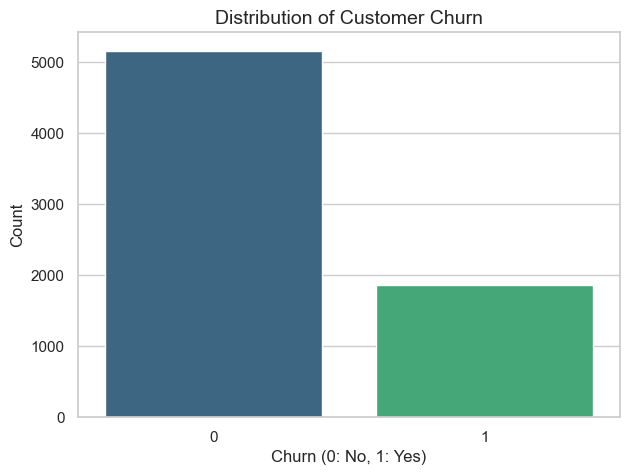

Churn Percentage:
 Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


In [4]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribution of Customer Churn', fontsize=14)
plt.xlabel('Churn (0: No, 1: Yes)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

print("Churn Percentage:\n", df['Churn'].value_counts(normalize=True) * 100)

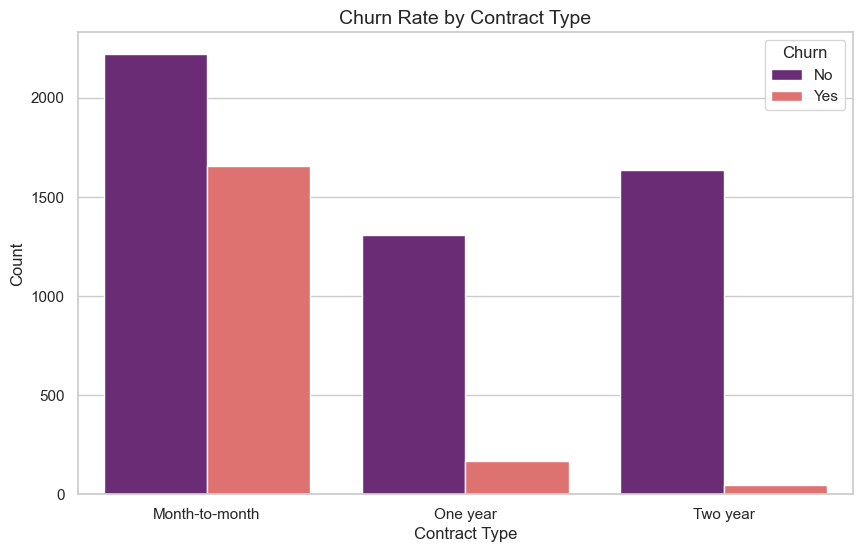

In [5]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df, palette='magma')
plt.title('Churn Rate by Contract Type', fontsize=14)
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.show()

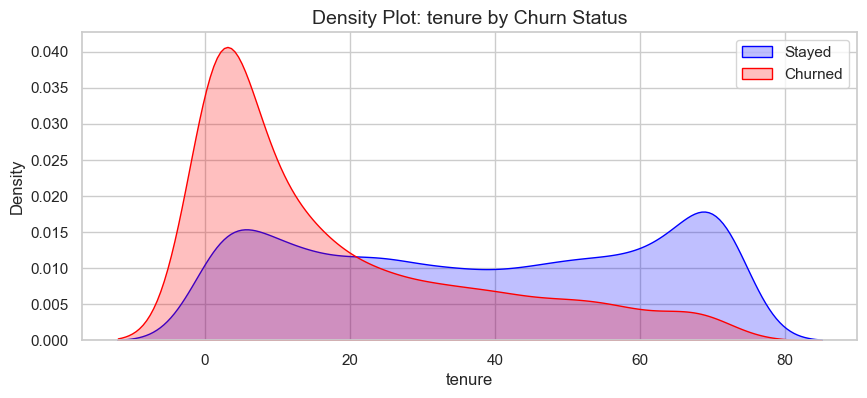

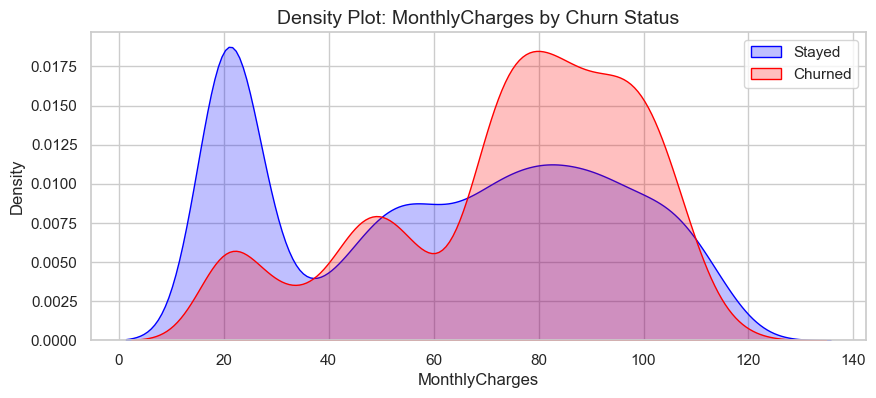

In [6]:
def plot_kde_analysis(feature):
    plt.figure(figsize=(10, 4))
    plt.title(f'Density Plot: {feature} by Churn Status', fontsize=14)
    sns.kdeplot(df[df['Churn'] == 0][feature], label='Stayed', shade=True, color='blue')
    sns.kdeplot(df[df['Churn'] == 1][feature], label='Churned', shade=True, color='red')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.legend()
    plt.show()

plot_kde_analysis('tenure')
plot_kde_analysis('MonthlyCharges')

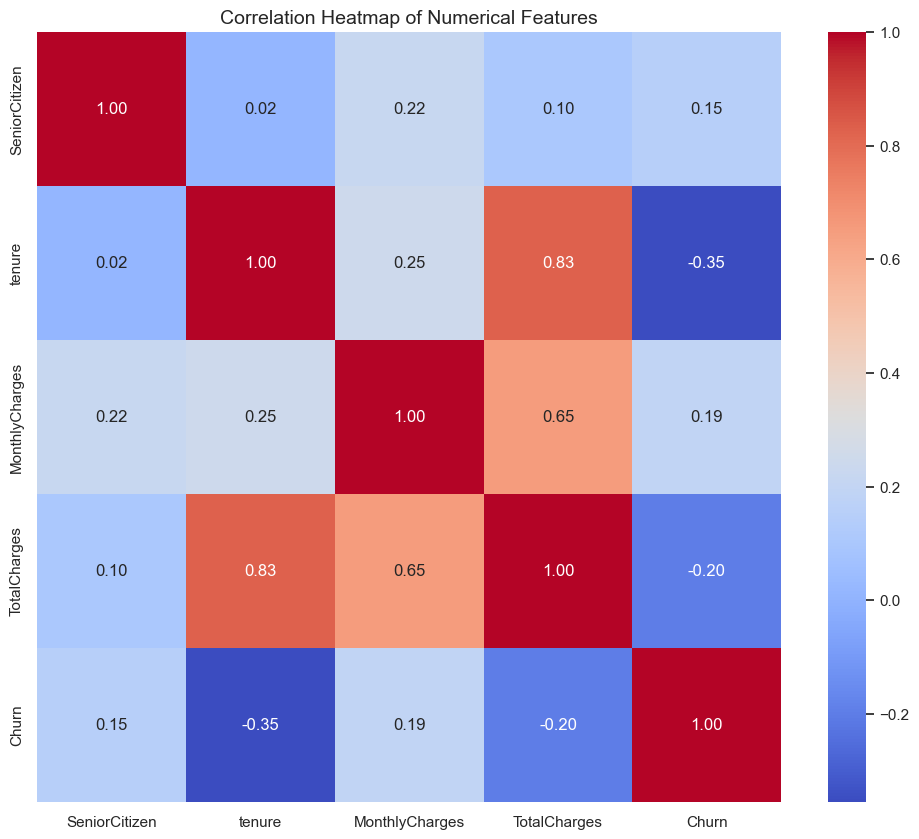

In [7]:
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.show()

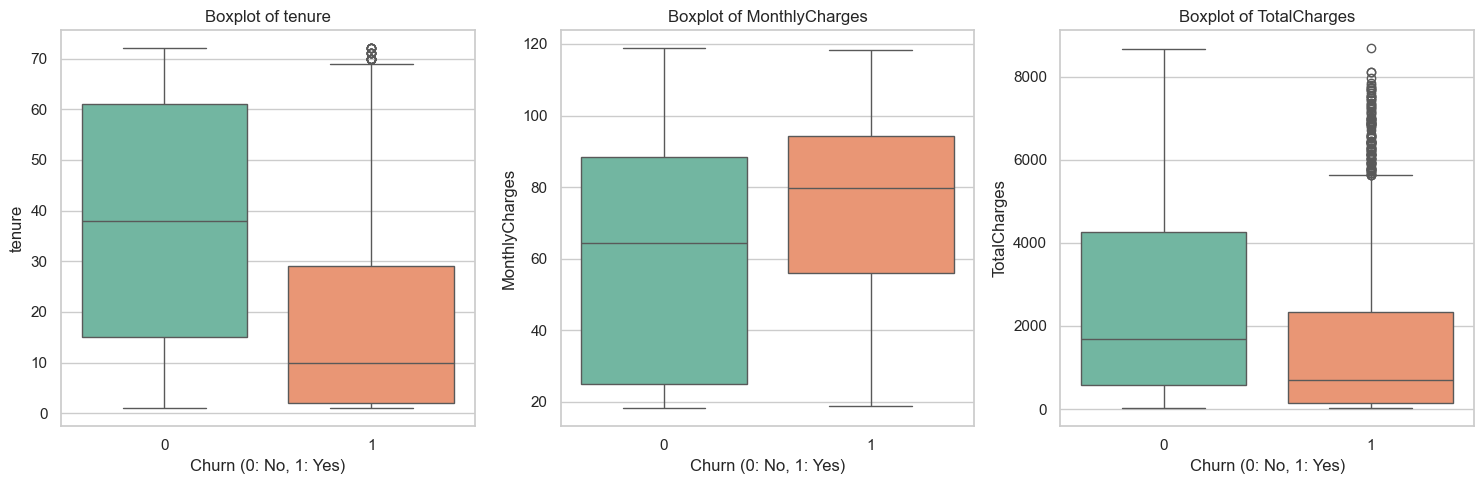

In [8]:
# List of numerical columns
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15, 5))

for i, feature in enumerate(num_features, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='Churn', y=feature, data=df, palette='Set2')
    plt.title(f'Boxplot of {feature}', fontsize=12)
    plt.xlabel('Churn (0: No, 1: Yes)')

plt.tight_layout()
plt.show()

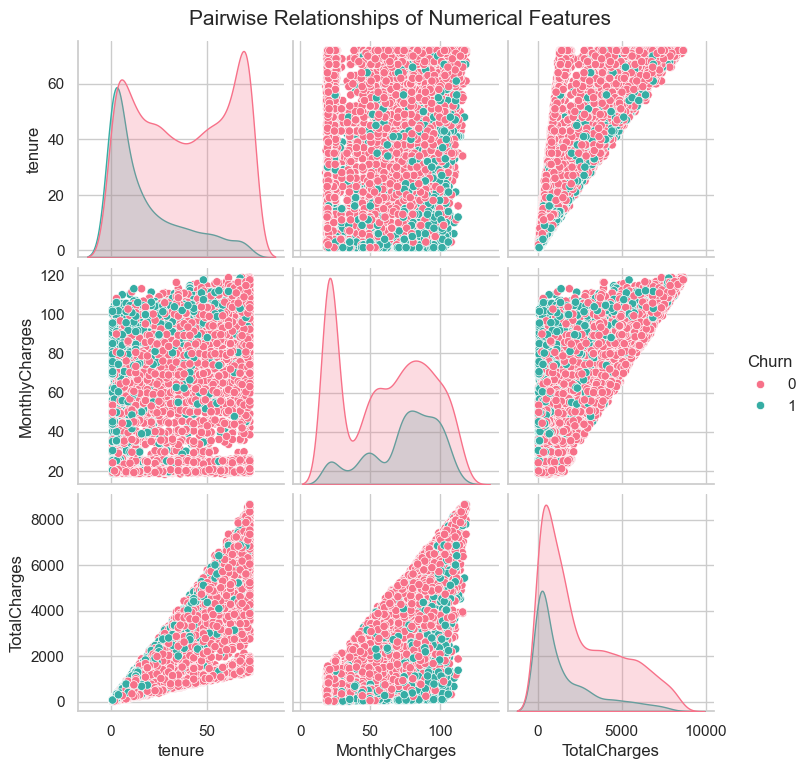

In [9]:
# Pairplot for numerical features colored by Churn
# We take a sample of the data (e.g., 1000 rows) to make it render faster
sns.pairplot(df[num_features + ['Churn']], hue='Churn', palette='husl', diag_kind='kde')
plt.suptitle('Pairwise Relationships of Numerical Features', y=1.02, fontsize=15)
plt.show()

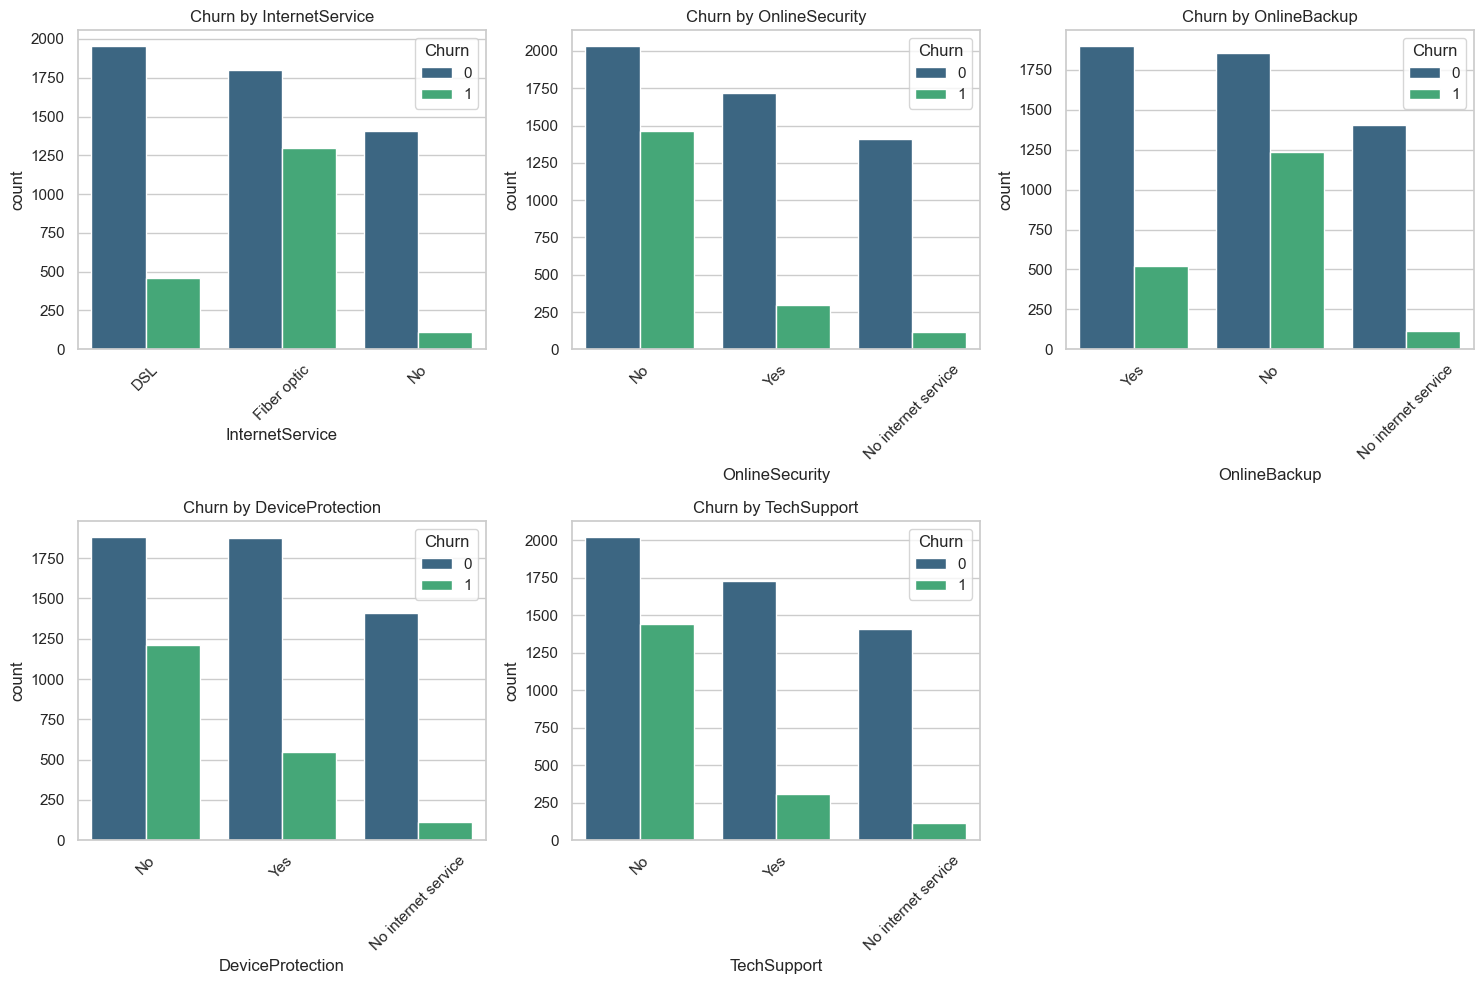

In [10]:
services = ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']

plt.figure(figsize=(15, 10))
for i, service in enumerate(services, 1):
    plt.subplot(2, 3, i)
    sns.countplot(x=service, hue='Churn', data=df, palette='viridis')
    plt.title(f'Churn by {service}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

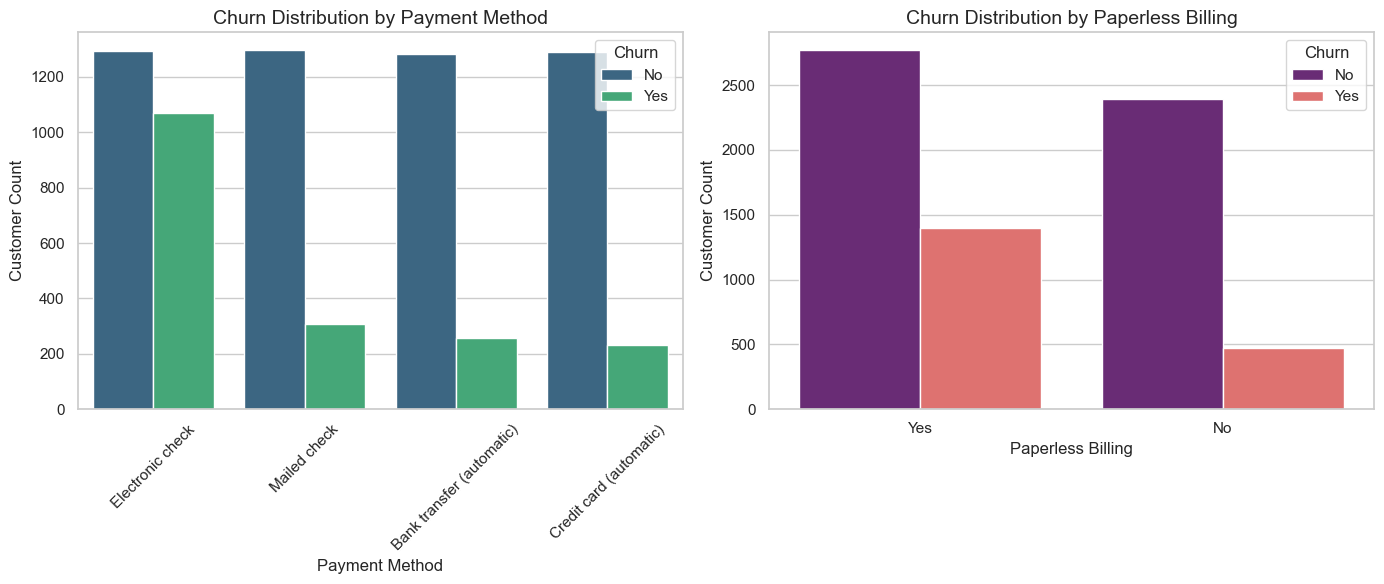

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots for Payment Method and Paperless Billing
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Churn by Payment Method
sns.countplot(data=df, x='PaymentMethod', hue='Churn', ax=axes[0], palette='viridis')
axes[0].set_title('Churn Distribution by Payment Method', fontsize=14)
axes[0].set_xlabel('Payment Method', fontsize=12)
axes[0].set_ylabel('Customer Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Churn', labels=['No', 'Yes'])

# Plot 2: Churn by Paperless Billing
sns.countplot(data=df, x='PaperlessBilling', hue='Churn', ax=axes[1], palette='magma')
axes[1].set_title('Churn Distribution by Paperless Billing', fontsize=14)
axes[1].set_xlabel('Paperless Billing', fontsize=12)
axes[1].set_ylabel('Customer Count', fontsize=12)
axes[1].legend(title='Churn', labels=['No', 'Yes'])

plt.tight_layout()
plt.savefig('churn_payment_billing.png', dpi=150)
plt.show()

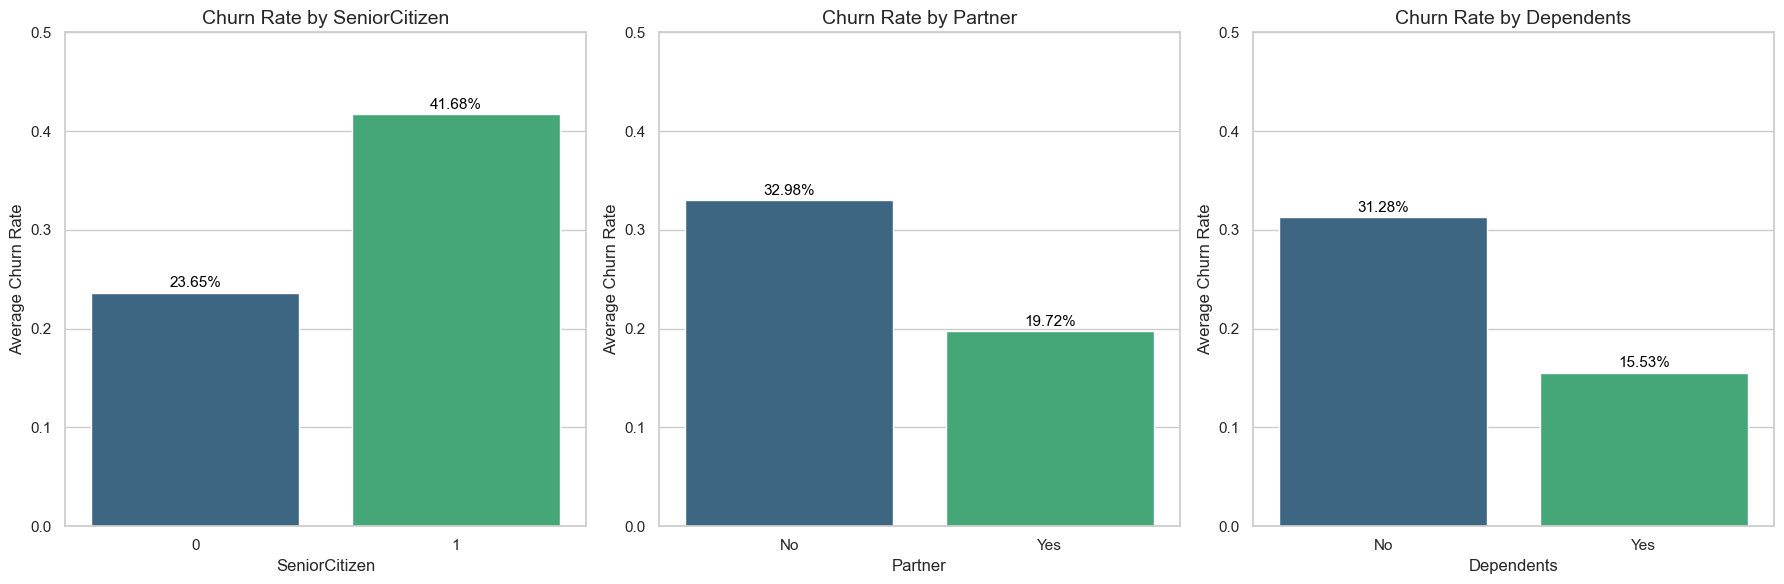

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure data is loaded and preprocessed
# df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
# df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Create subplots for Demographic Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
demographic_features = ['SeniorCitizen', 'Partner', 'Dependents']
colors = ['#4e79a7', '#f28e2b', '#e15759']

for i, col in enumerate(demographic_features):
    # Calculate average churn rate for each category
    churn_rate_data = df.groupby(col)['Churn'].mean().reset_index()
    
    # Plotting
    sns.barplot(data=churn_rate_data, x=col, y='Churn', ax=axes[i], palette='viridis')
    
    # Formatting
    axes[i].set_title(f'Churn Rate by {col}', fontsize=14)
    axes[i].set_ylabel('Average Churn Rate', fontsize=12)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylim(0, 0.5)  # Setting same scale for better comparison
    
    # Adding percentage labels on top of bars
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.2%}', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', 
                         fontsize=11, color='black', xytext=(0, 7), 
                         textcoords='offset points')

plt.tight_layout()
plt.savefig('churn_demographics.png', dpi=150)
plt.show()

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# ── ADIM 1: KATEGORİK DEĞİŞKENLERİ ENCODE ETME ──────────────

# 1. İki seçenekli (Binary) Yes/No sütunları → 0/1
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# 2. gender → 1: Male, 0: Female
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# 3. One-Hot Encoding — Çok kategorili (3 veya daha fazla) değişkenler
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 
              'OnlineBackup', 'DeviceProtection', 'TechSupport', 
              'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

# drop_first=True ile çoklu doğrusallık (Dummy Variable Trap) engellenir
df_encoded = pd.get_dummies(df, columns=multi_cols, drop_first=True)

# İstatistiksel testlerin (Chi-Square vb.) düzgün çalışması için True/False değerleri 1/0 (float) yapalım
df_encoded = df_encoded.astype(float)


# ── ADIM 2: TRAIN / TEST AYIRMA (STRATIFIED) ──────────────

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# %80 train, %20 test — stratified ile sınıf dengesi (26.5%) aynen korunur
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# ── ADIM 3: SMOTE (SADECE TRAIN SETİNE UYGULANIR) ──────────

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)


# ── ADIM 4: SAYISAL SÜTUNLARI ÖLÇEKLENDİRME (SCALING) ──────

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()

# Dengelenmiş Train setinde öğren ve uygula (fit_transform)
X_train_bal[numerical_cols] = scaler.fit_transform(X_train_bal[numerical_cols])

# Test setine sadece uygula (transform) - Sızıntıyı önlemek için fit edilmez!
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])


# ── KONTROL ÇIKTILARI ─────────────────────────────────────

print("=== VERİ HAZIRLIK RAPORU ===")
print(f"Orijinal Veri Boyutu: {df_encoded.shape}")
print(f"SMOTE Öncesi Train Sınıf Dağılımı: {y_train.value_counts().to_dict()}")
print(f"SMOTE Sonrası Train Sınıf Dağılımı: {pd.Series(y_train_bal).value_counts().to_dict()}")
print(f"Test Seti Boyutu: {X_test.shape}")
print(f"İşlem gören toplam sütun sayısı: {X_train_bal.shape[1]}")

=== VERİ HAZIRLIK RAPORU ===
Orijinal Veri Boyutu: (7032, 31)
SMOTE Öncesi Train Sınıf Dağılımı: {0.0: 4130, 1.0: 1495}
SMOTE Sonrası Train Sınıf Dağılımı: {0.0: 4130, 1.0: 4130}
Test Seti Boyutu: (1407, 30)
İşlem gören toplam sütun sayısı: 30


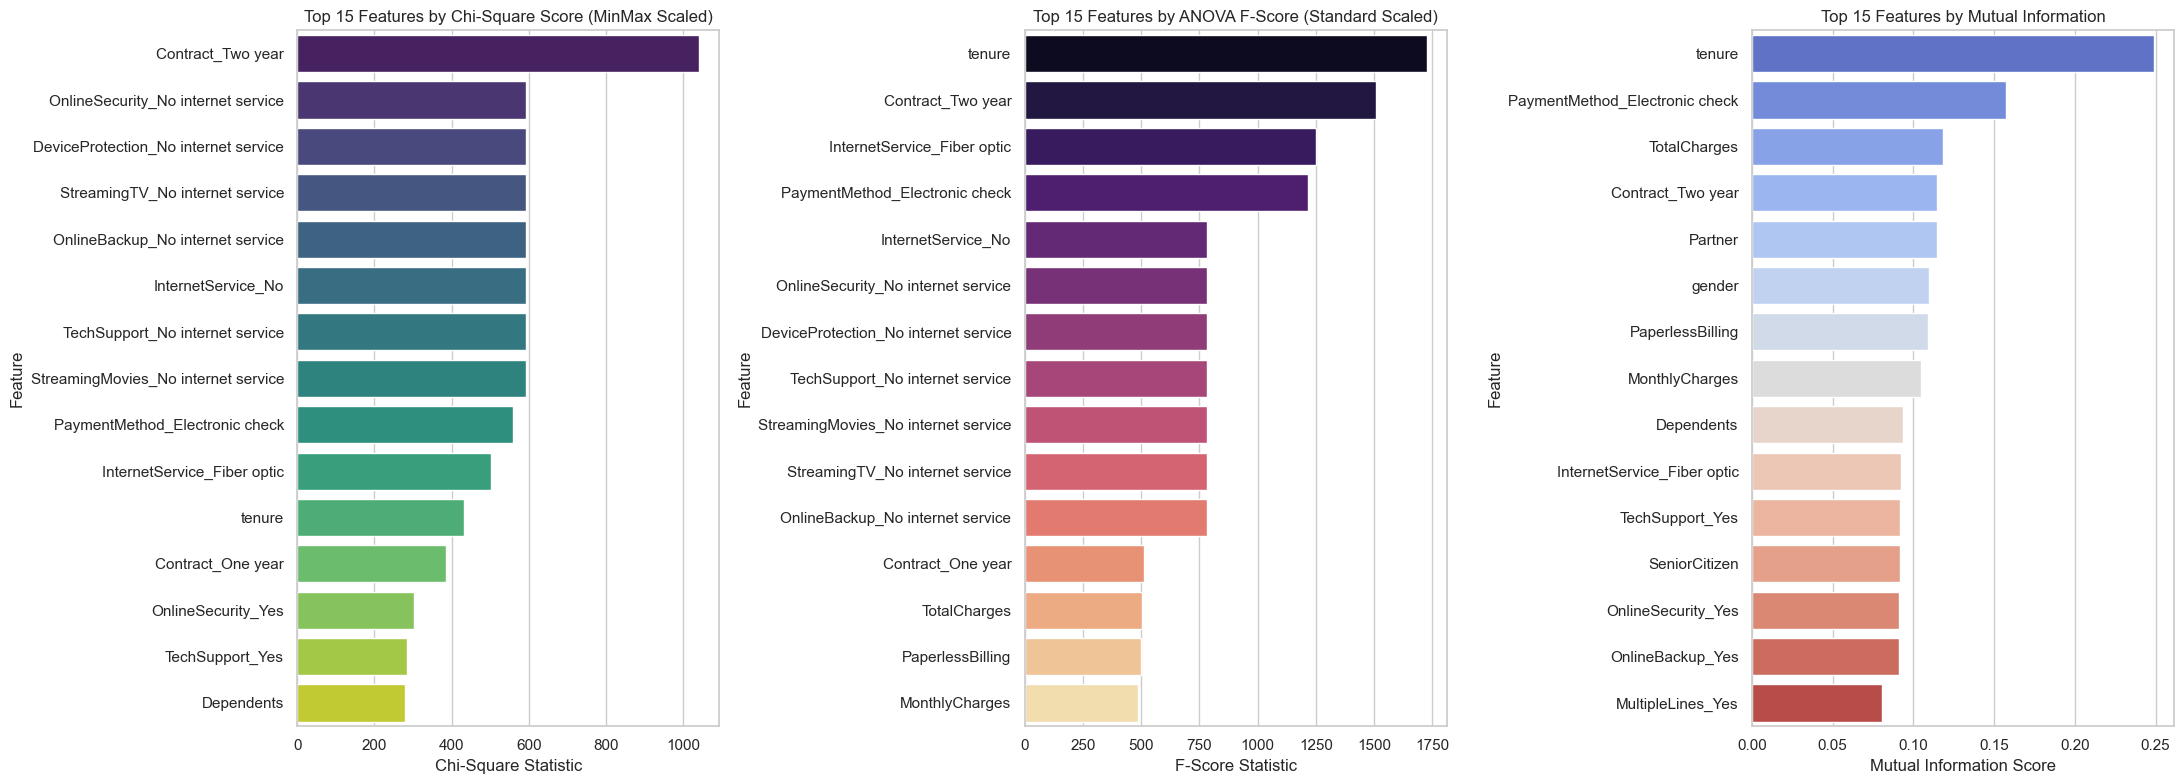

--- FİLTRELEME YÖNTEMLERİ EN GÜVENLİ HALE GETİRİLDİ VE GRAFİK BASILDI ---


In [14]:
from sklearn.feature_selection import SelectKBest, chi2, f_classif, mutual_info_classif
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 0. CHI-SQUARE İÇİN ÖZEL [0, 1] ÖLÇEKLENDİRME ---
# Sadece Chi-Square negatif değer sevmediği için bu testi MinMaxScaler verisiyle besleyeceğiz.
# Index kaybını önlemek için index=X_train_bal.index parametresini de ekliyoruz.
X_train_minmax = pd.DataFrame(
    MinMaxScaler().fit_transform(X_train_bal),
    columns=X_train_bal.columns,
    index=X_train_bal.index
)

# --- A. CHI-SQUARE TEST ---
chi2_selector = SelectKBest(score_func=chi2, k='all')
chi2_selector.fit(X_train_minmax, y_train_bal)

df_chi2 = pd.DataFrame({
    'Feature': X_train_bal.columns,
    'Chi2_Score': chi2_selector.scores_,
    'p_value': chi2_selector.pvalues_  # ✅ İstatistiksel anlamlılık için eklendi
}).sort_values(by='Chi2_Score', ascending=False)


# --- B. ANOVA F-TEST ---
anova_selector = SelectKBest(score_func=f_classif, k='all')
anova_selector.fit(X_train_bal, y_train_bal)

df_anova = pd.DataFrame({
    'Feature': X_train_bal.columns,
    'F_Score': anova_selector.scores_,
    'p_value': anova_selector.pvalues_  # ✅ İstatistiksel anlamlılık için eklendi
}).sort_values(by='F_Score', ascending=False)


# --- C. MUTUAL INFORMATION ---
# MI hem doğrusal olmayan ilişkileri ölçtüğü için standart veriyle harika çalışır.
mi_scores = mutual_info_classif(X_train_bal, y_train_bal, random_state=42)

df_mi = pd.DataFrame({
    'Feature': X_train_bal.columns,
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)


# --- SONUÇLARI GÖRSELLEŞTİRME ---
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

# Chi-Square Grafiği (Top 15)
sns.barplot(data=df_chi2.head(15), x='Chi2_Score', y='Feature', ax=axes[0], palette='viridis')
axes[0].set_title('Top 15 Features by Chi-Square Score (MinMax Scaled)', fontsize=12)
axes[0].set_xlabel('Chi-Square Statistic')

# ANOVA F-Test Grafiği (Top 15)
sns.barplot(data=df_anova.head(15), x='F_Score', y='Feature', ax=axes[1], palette='magma')
axes[1].set_title('Top 15 Features by ANOVA F-Score (Standard Scaled)', fontsize=12)
axes[1].set_xlabel('F-Score Statistic')

# Mutual Information Grafiği (Top 15)
sns.barplot(data=df_mi.head(15), x='MI_Score', y='Feature', ax=axes[2], palette='coolwarm')
axes[2].set_title('Top 15 Features by Mutual Information', fontsize=12)
axes[2].set_xlabel('Mutual Information Score')

plt.tight_layout()
plt.savefig('filter_methods_results.png', dpi=150)
plt.show()

print("--- FİLTRELEME YÖNTEMLERİ EN GÜVENLİ HALE GETİRİLDİ VE GRAFİK BASILDI ---")

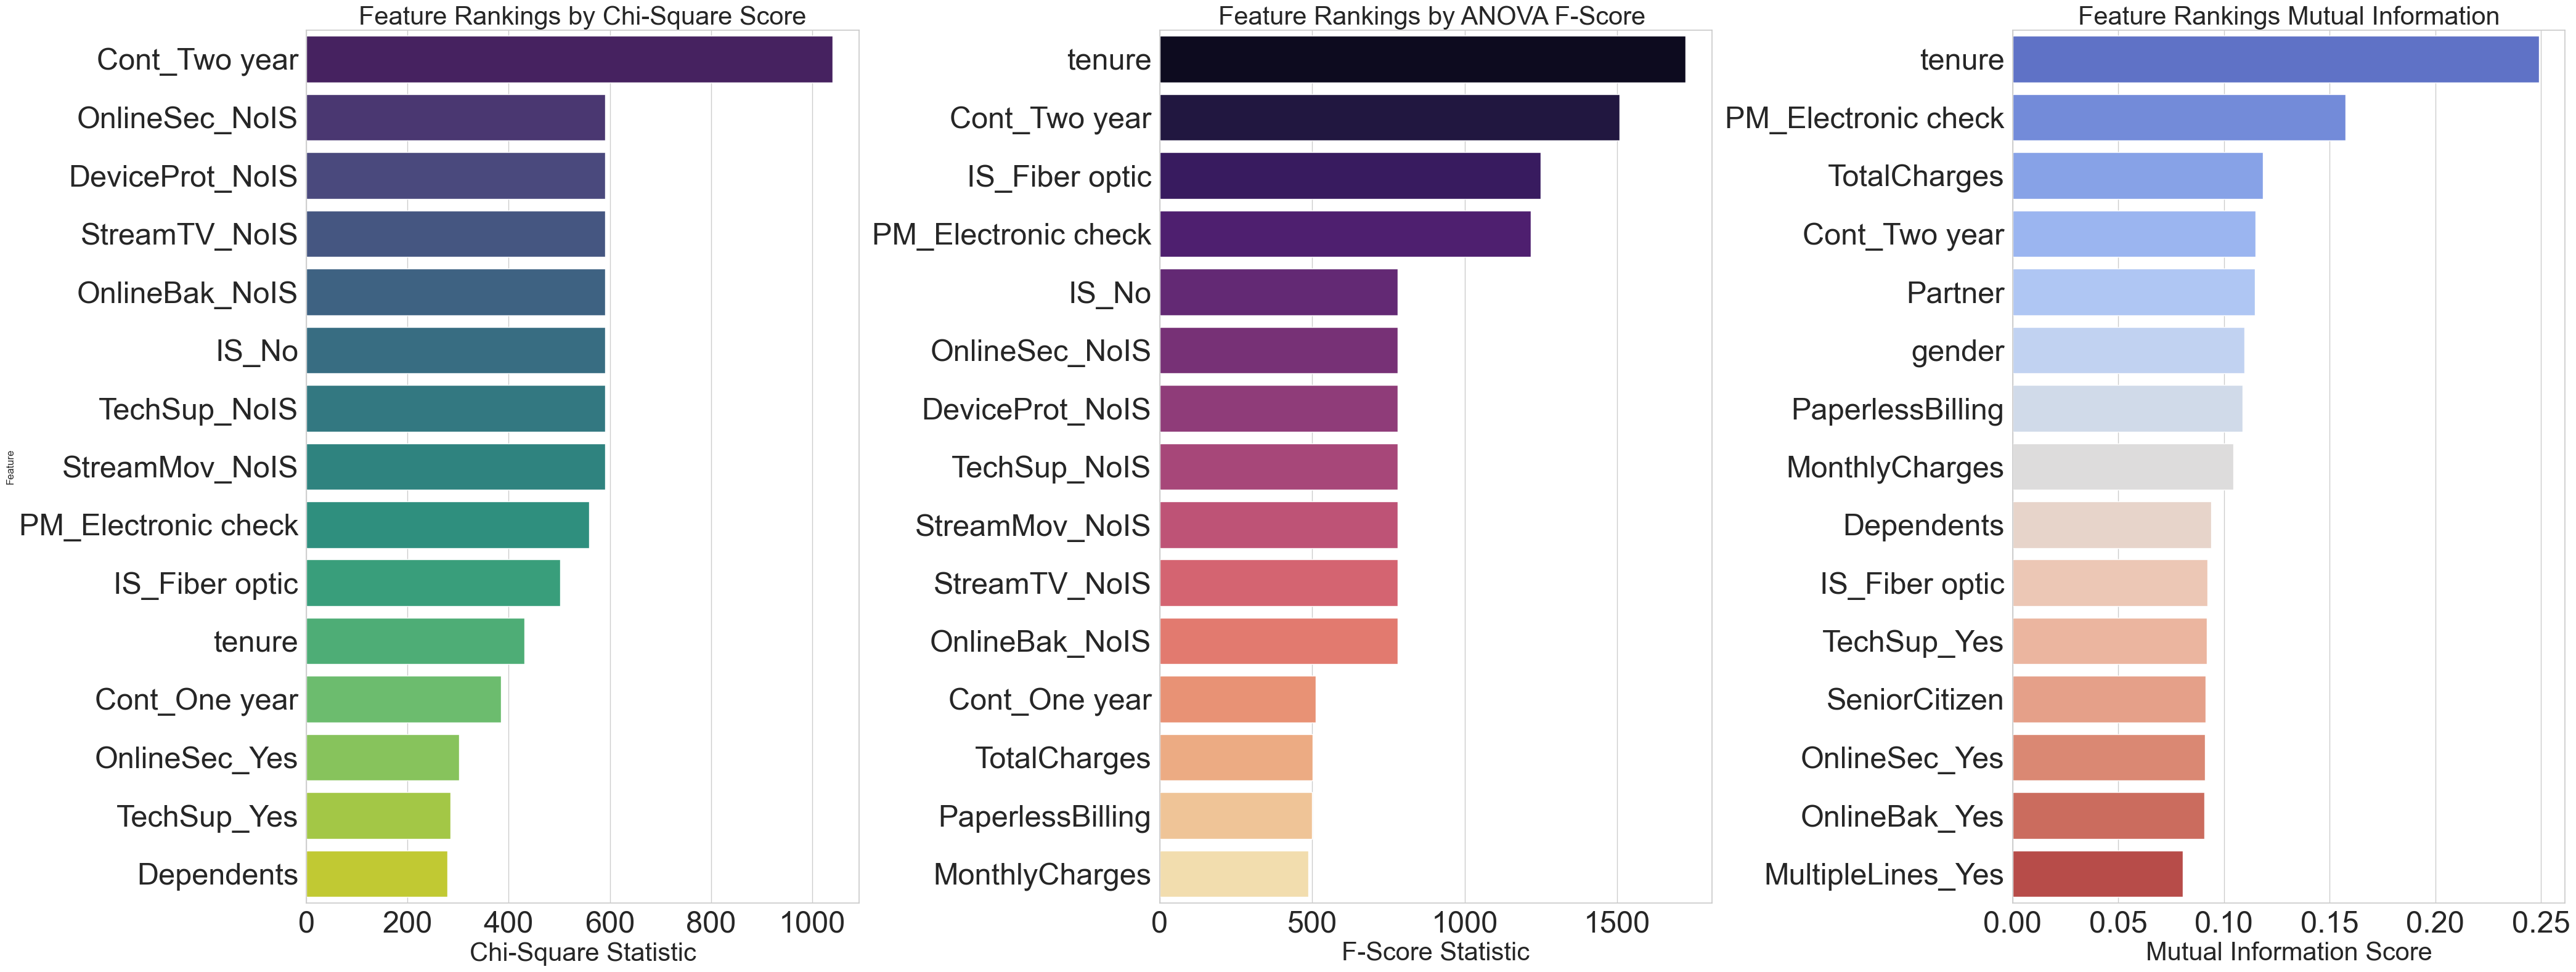

--- TAMAMLANDI ---


In [15]:
from sklearn.feature_selection import SelectKBest, chi2, f_classif, mutual_info_classif
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 14})

def shorten_name(name):
    return (name.replace('_No internet service', '_NoIS')
                .replace('PaymentMethod_', 'PM_')
                .replace('InternetService_', 'IS_')
                .replace('Contract_', 'Cont_')
                .replace('OnlineSecurity', 'OnlineSec')
                .replace('DeviceProtection', 'DeviceProt')
                .replace('StreamingMovies', 'StreamMov')
                .replace('StreamingTV', 'StreamTV')
                .replace('OnlineBackup', 'OnlineBak')
                .replace('TechSupport', 'TechSup'))

# --- 0. CHI-SQUARE İÇİN MinMax ÖLÇEKLENDİRME ---
X_train_minmax = pd.DataFrame(
    MinMaxScaler().fit_transform(X_train_bal),
    columns=X_train_bal.columns,
    index=X_train_bal.index
)

# --- A. CHI-SQUARE TEST ---
chi2_selector = SelectKBest(score_func=chi2, k='all')
chi2_selector.fit(X_train_minmax, y_train_bal)

df_chi2 = pd.DataFrame({
    'Feature': X_train_bal.columns,
    'Chi2_Score': chi2_selector.scores_,
    'p_value': chi2_selector.pvalues_
}).sort_values(by='Chi2_Score', ascending=False)
df_chi2['Feature'] = df_chi2['Feature'].apply(shorten_name)

# --- B. ANOVA F-TEST ---
anova_selector = SelectKBest(score_func=f_classif, k='all')
anova_selector.fit(X_train_bal, y_train_bal)

df_anova = pd.DataFrame({
    'Feature': X_train_bal.columns,
    'F_Score': anova_selector.scores_,
    'p_value': anova_selector.pvalues_
}).sort_values(by='F_Score', ascending=False)
df_anova['Feature'] = df_anova['Feature'].apply(shorten_name)

# --- C. MUTUAL INFORMATION ---
mi_scores = mutual_info_classif(X_train_bal, y_train_bal, random_state=42)

df_mi = pd.DataFrame({
    'Feature': X_train_bal.columns,
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)
df_mi['Feature'] = df_mi['Feature'].apply(shorten_name)

# --- GÖRSELLEŞTİRME ---
fig, axes = plt.subplots(1, 3, figsize=(42, 16))

sns.barplot(data=df_chi2.head(15), x='Chi2_Score', y='Feature', ax=axes[0], palette='viridis')
axes[0].set_title('Feature Rankings by Chi-Square Score', fontsize=30)
axes[0].set_xlabel('Chi-Square Statistic', fontsize=30)
axes[0].tick_params(axis='both', labelsize=35)

sns.barplot(data=df_anova.head(15), x='F_Score', y='Feature', ax=axes[1], palette='magma')
axes[1].set_title('Feature Rankings by ANOVA F-Score ', fontsize=30)
axes[1].set_xlabel('F-Score Statistic', fontsize=30)
axes[1].set_ylabel('')
axes[1].tick_params(axis='both', labelsize=35)

sns.barplot(data=df_mi.head(15), x='MI_Score', y='Feature', ax=axes[2], palette='coolwarm')
axes[2].set_title('Feature Rankings Mutual Information', fontsize=30)
axes[2].set_xlabel('Mutual Information Score', fontsize=30)
axes[2].set_ylabel('')
axes[2].tick_params(axis='both', labelsize=35)

plt.tight_layout()
plt.savefig('filter_methods_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("--- TAMAMLANDI ---")

In [16]:
import pandas as pd

# Pandas'ın çıktıları kırpmasını (kullanışsız üç noktaları) tamamen engelliyoruz
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)

print("="*31 + " TOP 10 CHI-SQUARE FEATURES " + "="*31)
print(df_chi2.head(15).to_string(index=False, formatters={'Chi2_Score': '{:,.2f}'.format, 'p_value': '{:.6f}'.format}))

print("\n" + "="*32 + " TOP 10 ANOVA F-TEST FEATURES " + "="*32)
print(df_anova.head(15).to_string(index=False, formatters={'F_Score': '{:,.2f}'.format, 'p_value': '{:.6f}'.format}))

print("\n" + "="*30 + " TOP 10 MUTUAL INFORMATION FEATURES " + "="*30)
print(df_mi.head(15).to_string(index=False, formatters={'MI_Score': '{:.6f}'.format}))

=============================== TOP 10 CHI-SQUARE FEATURES ===============================
            Feature Chi2_Score  p_value
      Cont_Two year   1,040.79 0.000000
     OnlineSec_NoIS     591.03 0.000000
    DeviceProt_NoIS     591.03 0.000000
      StreamTV_NoIS     591.03 0.000000
     OnlineBak_NoIS     591.03 0.000000
              IS_No     591.03 0.000000
       TechSup_NoIS     591.03 0.000000
     StreamMov_NoIS     591.03 0.000000
PM_Electronic check     559.49 0.000000
     IS_Fiber optic     501.83 0.000000
             tenure     431.46 0.000000
      Cont_One year     384.33 0.000000
      OnlineSec_Yes     301.43 0.000000
        TechSup_Yes     285.06 0.000000
         Dependents     278.91 0.000000

================================ TOP 10 ANOVA F-TEST FEATURES ================================
            Feature  F_Score  p_value
             tenure 1,724.83 0.000000
      Cont_Two year 1,507.99 0.000000
     IS_Fiber optic 1,250.25 0.000000
PM_Electronic check 1

In [ ]:
# --- FİLTRELEME YÖNTEMLERİ P-VALUE VE SKOR RAPORU ---

print("="*30 + " TOP 10 CHI-SQUARE FEATURES " + "="*30)
# index=False ile sol taraftaki karmaşık satır numaralarını gizliyoruz
print(df_chi2.head(10).to_string(index=False, formatters={'Chi2_Score': '{:,.2f}'.format, 'p_value': '{:.6f}'.format}))

print("\n" + "="*31 + " TOP 10 ANOVA F-TEST FEATURES " + "="*31)
print(df_anova.head(10).to_string(index=False, formatters={'F_Score': '{:,.2f}'.format, 'p_value': '{:.6f}'.format}))

print("\n" + "="*29 + " TOP 10 MUTUAL INFORMATION FEATURES " + "="*29)
# MI skorunu da diğerleri gibi hizalı ve formatlı bir şekilde bastırıyoruz
print(df_mi.head(10).to_string(index=False, formatters={'MI_Score': '{:.6f}'.format}))

============================== TOP 10 CHI-SQUARE FEATURES ==============================
            Feature Chi2_Score  p_value
      Cont_Two year   1,040.79 0.000000
     OnlineSec_NoIS     591.03 0.000000
    DeviceProt_NoIS     591.03 0.000000
      StreamTV_NoIS     591.03 0.000000
     OnlineBak_NoIS     591.03 0.000000
              IS_No     591.03 0.000000
       TechSup_NoIS     591.03 0.000000
     StreamMov_NoIS     591.03 0.000000
PM_Electronic check     559.49 0.000000
     IS_Fiber optic     501.83 0.000000

=============================== TOP 10 ANOVA F-TEST FEATURES ===============================
            Feature  F_Score  p_value
             tenure 1,724.83 0.000000
      Cont_Two year 1,507.99 0.000000
     IS_Fiber optic 1,250.25 0.000000
PM_Electronic check 1,217.95 0.000000
              IS_No   780.64 0.000000
     OnlineSec_NoIS   780.64 0.000000
    DeviceProt_NoIS   780.64 0.000000
       TechSup_NoIS   780.64 0.000000
     StreamMov_NoIS   780.64 0.0000

In [18]:
from sklearn.linear_model import LogisticRegression
import numpy as np

for c in [0.001, 0.005, 0.01, 0.05, 0.1]:
    m = LogisticRegression(penalty='l1', solver='saga',
                           C=c, max_iter=2000, random_state=42)
    m.fit(X_train_bal, y_train_bal)
    n_selected = np.sum(m.coef_[0] != 0)
    n_zero     = np.sum(m.coef_[0] == 0)
    print(f"C={c:.3f}  →  Seçilen: {n_selected}  |  Elenen: {n_zero}")


    

C=0.001  →  Seçilen: 2  |  Elenen: 28
C=0.005  →  Seçilen: 6  |  Elenen: 24
C=0.010  →  Seçilen: 10  |  Elenen: 20
C=0.050  →  Seçilen: 24  |  Elenen: 6
C=0.100  →  Seçilen: 26  |  Elenen: 4


========================= GENERAL RFECV RANKING =========================
                              Feature  Selected  RFECV_Ranking
                           Dependents      True              1
                     PaperlessBilling      True              1
                         PhoneService      True              1
                               tenure      True              1
                       MonthlyCharges      True              1
          InternetService_Fiber optic      True              1
                    MultipleLines_Yes      True              1
                         TotalCharges      True              1
                   OnlineSecurity_Yes      True              1
   OnlineSecurity_No internet service      True              1
     OnlineBackup_No internet service      True              1
                   InternetService_No      True              1
                      TechSupport_Yes      True              1
      TechSupport_No internet service      T

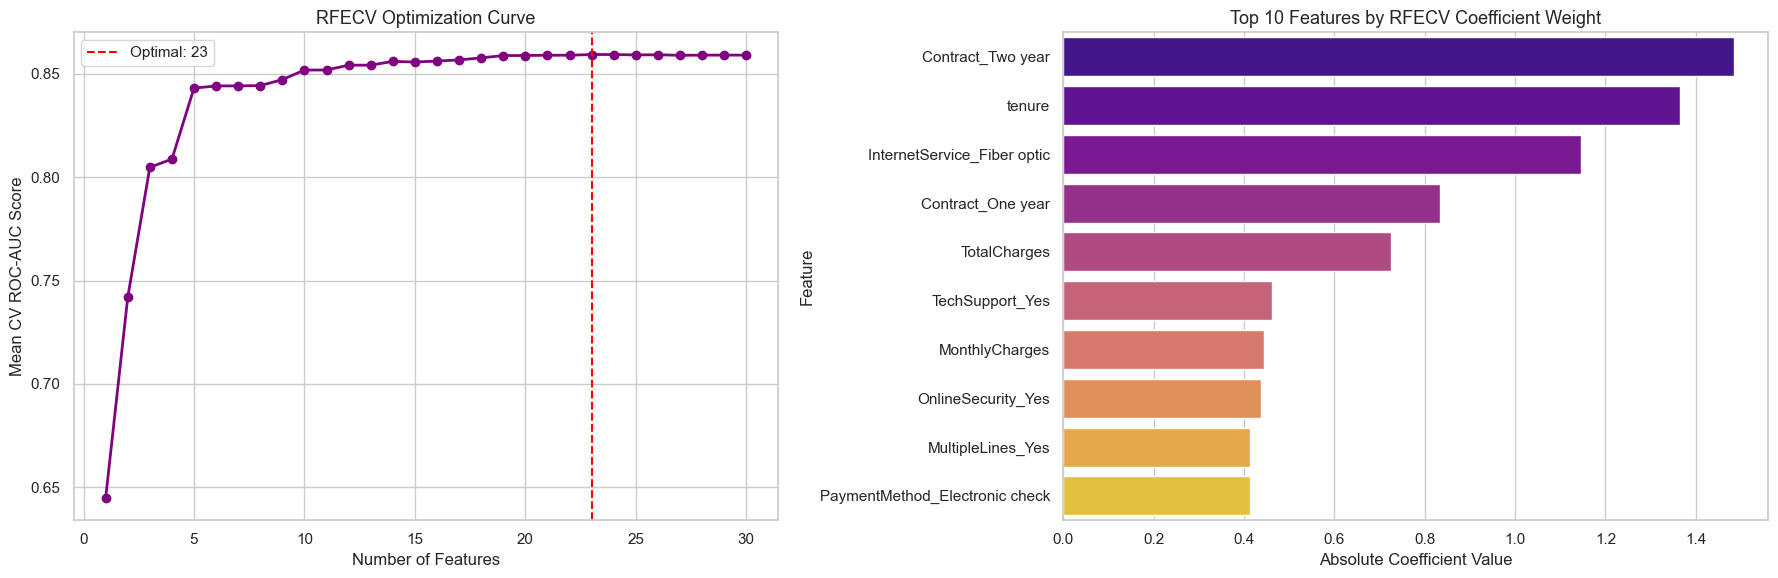


==================== WRAPPER METHOD: TOP 10 FEATURES ====================
                       Feature  Importance_Weight
             Contract_Two year           1.485663
                        tenure           1.364611
   InternetService_Fiber optic           1.146091
             Contract_One year           0.833421
                  TotalCharges           0.726259
               TechSupport_Yes           0.460986
                MonthlyCharges           0.443576
            OnlineSecurity_Yes           0.436799
             MultipleLines_Yes           0.414107
PaymentMethod_Electronic check           0.413175

Final feature sayısı: 17
['Contract_Two year', 'tenure', 'InternetService_Fiber optic', 'Contract_One year', 'TotalCharges', 'TechSupport_Yes', 'MonthlyCharges', 'OnlineSecurity_Yes', 'MultipleLines_Yes', 'PaymentMethod_Electronic check', 'StreamingMovies_Yes', 'PhoneService', 'StreamingTV_Yes', 'Dependents', 'PaperlessBilling', 'OnlineBackup_Yes', 'InternetService_No']


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(estimator=log_reg, step=1, cv=cv_strategy,
              scoring='roc_auc', n_jobs=-1)
rfecv.fit(X_train_bal, y_train_bal)

# Genel ranking tablosu
df_rfecv_all = pd.DataFrame({
    'Feature': X_train_bal.columns,
    'Selected': rfecv.support_,
    'RFECV_Ranking': rfecv.ranking_
}).sort_values(by='RFECV_Ranking')

print("="*25 + " GENERAL RFECV RANKING " + "="*25)
print(df_rfecv_all.to_string(index=False))

df_rfecv_selected = df_rfecv_all[df_rfecv_all['Selected'] == True]
print(f"\nRFECV Tarafından Seçilen Toplam Özellik Sayısı: {len(df_rfecv_selected)}")

# ✅ DÜZELTME — doğru eşleştirme
selected_feature_names = X_train_bal.columns[rfecv.support_]
rfecv_coefs = np.abs(rfecv.estimator_.coef_[0])

df_wrapper_final = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance_Weight': rfecv_coefs
}).sort_values(by='Importance_Weight', ascending=False)

df_wrapper_top10 = df_wrapper_final.head(10)

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(18 , 6))

cv_scores = rfecv.cv_results_['mean_test_score']
axes[0].plot(range(1, len(cv_scores) + 1), cv_scores,
             marker='o', color='purple', linewidth=2)
axes[0].axvline(x=rfecv.n_features_, color='red', linestyle='--',
                label=f'Optimal: {rfecv.n_features_}')
axes[0].set_title('RFECV Optimization Curve', fontsize=13)
axes[0].set_xlabel('Number of Features')
axes[0].set_ylabel('Mean CV ROC-AUC Score')
axes[0].legend()
axes[0].grid(True)

sns.barplot(data=df_wrapper_top10, x='Importance_Weight',
            y='Feature', ax=axes[1], palette='plasma')
axes[1].set_title('Top 10 Features by RFECV Coefficient Weight', fontsize=13)
axes[1].set_xlabel('Absolute Coefficient Value')

plt.tight_layout()

plt.savefig('wrapper_methods_results.png', dpi=150)
plt.show()

print("\n" + "="*20 + " WRAPPER METHOD: TOP 10 FEATURES " + "="*20)
print(df_wrapper_top10.to_string(index=False))

no_internet_dummies = [
    'OnlineSecurity_No internet service',
    'OnlineBackup_No internet service',
    'TechSupport_No internet service',
    'DeviceProtection_No internet service',
    'StreamingTV_No internet service',
    'StreamingMovies_No internet service'
]

wrapper_selected_features_list = [
    f for f in df_wrapper_final['Feature'].tolist()
    if f not in no_internet_dummies
]

print(f"\nFinal feature sayısı: {len(wrapper_selected_features_list)}")
print(wrapper_selected_features_list)

In [21]:
from sklearn.linear_model import LogisticRegression
import numpy as np

for c in [0.001, 0.005, 0.01, 0.05, 0.1]:
    m = LogisticRegression(penalty='l1', solver='saga',
                           C=c, max_iter=2000, random_state=42)
    m.fit(X_train_bal, y_train_bal)
    n_selected = np.sum(m.coef_[0] != 0)
    n_zero     = np.sum(m.coef_[0] == 0)
    print(f"C={c:.3f}  →  Seçilen: {n_selected}  |  Elenen: {n_zero}")

C=0.001  →  Seçilen: 2  |  Elenen: 28
C=0.005  →  Seçilen: 6  |  Elenen: 24
C=0.010  →  Seçilen: 10  |  Elenen: 20
C=0.050  →  Seçilen: 24  |  Elenen: 6
C=0.100  →  Seçilen: 26  |  Elenen: 4


In [ ]:
# 1) Korelasyon kontrolü — yüksek korelasyonlu çiftler var mı?----lasso için
corr_matrix = X_train_bal[final_selected_features].corr().abs()
high_corr = (corr_matrix > 0.85).sum().sum() - len(final_selected_features)
print(f"Yüksek korelasyonlu çift sayısı (>0.85): {high_corr // 2}")

Yüksek korelasyonlu çift sayısı (>0.85): 23


In [24]:
# ── ADIM 1: Korelasyon bazlı eleme ──────────────────────────────
def remove_high_corr(df, threshold=0.85):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    # Her korelasyonlu çiftten birini ele
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return df.drop(columns=to_drop), to_drop

X_train_clean, dropped_cols = remove_high_corr(X_train_bal, threshold=0.85)
X_test_clean = X_test.drop(columns=dropped_cols, errors='ignore')

print(f"Elenen (korelasyon): {len(dropped_cols)} özellik → {dropped_cols}")
print(f"Kalan özellik sayısı: {X_train_clean.shape[1]}")

Elenen (korelasyon): 8 özellik → ['TotalCharges', 'MultipleLines_No phone service', 'OnlineSecurity_No internet service', 'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 'TechSupport_No internet service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service']
Kalan özellik sayısı: 22


In [25]:
# ── ADIM 2: Temizlenmiş veriyle LASSO'yu yeniden çalıştır ───────
lasso_clean = LogisticRegressionCV(
    Cs=np.logspace(-4, 0, 30),
    penalty='l1',
    solver='saga',
    cv=5,
    scoring='roc_auc',
    max_iter=2000,
    random_state=42,
    n_jobs=-1
)
lasso_clean.fit(X_train_clean, y_train_bal)
optimal_c = lasso_clean.C_[0]

df_clean = pd.DataFrame({
    'Feature': X_train_clean.columns,
    'Coefficient': lasso_clean.coef_[0],
    'Absolute_Coefficient': np.abs(lasso_clean.coef_[0])
}).sort_values(by='Absolute_Coefficient', ascending=False)

df_selected_clean = df_clean[df_clean['Coefficient'] != 0]
df_eliminated_clean = df_clean[df_clean['Coefficient'] == 0]

print(f"\nOptimal C     : {optimal_c:.4f}")
print(f"Seçilen       : {len(df_selected_clean)}")
print(f"Elenen        : {len(df_eliminated_clean)}")


Optimal C     : 0.2043
Seçilen       : 19
Elenen        : 3


In [26]:
# ── ADIM 3: AUC karşılaştır ─────────────────────────────────────
from sklearn.metrics import roc_auc_score

# Eski model (korelasyonlu)
auc_old = roc_auc_score(y_test, 
    LogisticRegression(penalty='l1', solver='saga', C=optimal_c, max_iter=2000)
    .fit(X_train_bal, y_train_bal)
    .predict_proba(X_test)[:,1])

# Yeni model (temizlenmiş)
auc_new = roc_auc_score(y_test,
    LogisticRegression(penalty='l1', solver='saga', C=optimal_c, max_iter=2000)
    .fit(X_train_clean, y_train_bal)
    .predict_proba(X_test_clean)[:,1])

print(f"AUC (korelasyonlu) : {auc_old:.4f}")
print(f"AUC (temizlenmiş)  : {auc_new:.4f}")
print(f"Fark               : {abs(auc_old - auc_new):.4f}")

AUC (korelasyonlu) : 0.8350
AUC (temizlenmiş)  : 0.8329
Fark               : 0.0021


In [27]:
# Bundan sonra tüm adımlarda bu değişkenleri kullanın
X_train_bal = X_train_clean
X_test = X_test_clean
final_selected_features = df_selected_clean['Feature'].tolist()

print(f"✓ Aktif özellik seti: {len(final_selected_features)} özellik")
print(f"✓ Hedef AUC: {auc_new:.4f}")
print(final_selected_features)

✓ Aktif özellik seti: 19 özellik
✓ Hedef AUC: 0.8329
['Contract_Two year', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'tenure', 'TechSupport_Yes', 'PhoneService', 'OnlineSecurity_Yes', 'PaymentMethod_Electronic check', 'MultipleLines_Yes', 'PaperlessBilling', 'StreamingMovies_Yes', 'StreamingTV_Yes', 'Dependents', 'OnlineBackup_Yes', 'SeniorCitizen', 'Partner', 'DeviceProtection_Yes', 'MonthlyCharges']


In [29]:
print(f"Korelasyon sonrası kalan : {X_train_clean.shape[1]}")
print(f"LASSO sonrası seçilen   : {len(final_selected_features)}")
print()
print("Seçilen özellikler:")
for i, row in enumerate(df_selected_clean[['Feature','Coefficient']].values, 1):
    print(f"  {i:2}. {row[0]:<35} {row[1]:+.4f}")

Korelasyon sonrası kalan : 22
LASSO sonrası seçilen   : 19

Seçilen özellikler:
   1. Contract_Two year                   -1.3934
   2. InternetService_Fiber optic         +0.9357
   3. InternetService_No                  -0.8416
   4. Contract_One year                   -0.7897
   5. tenure                              -0.7659
   6. TechSupport_Yes                     -0.4536
   7. PhoneService                        -0.4514
   8. OnlineSecurity_Yes                  -0.4374
   9. PaymentMethod_Electronic check      +0.3890
  10. MultipleLines_Yes                   +0.3669
  11. PaperlessBilling                    +0.3187
  12. StreamingMovies_Yes                 +0.3128
  13. StreamingTV_Yes                     +0.3085
  14. Dependents                          -0.2910
  15. OnlineBackup_Yes                    -0.1822
  16. SeniorCitizen                       +0.1620
  17. Partner                             -0.0569
  18. DeviceProtection_Yes                +0.0124
  19. MonthlyCharges

Elenen (korelasyon) : 0 özellik → []
Kalan özellik sayısı: 22

Optimal C (CV): 0.2043
LASSO seçilen  : 19
LASSO elenen   : 3 → ['gender', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Mailed check']

Eşik filtresi elenen: ['MonthlyCharges']
Final özellik sayısı: 18

Test AUC: 0.8324

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.72      0.80      1033
         1.0       0.50      0.76      0.60       374

    accuracy                           0.73      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.73      0.75      1407



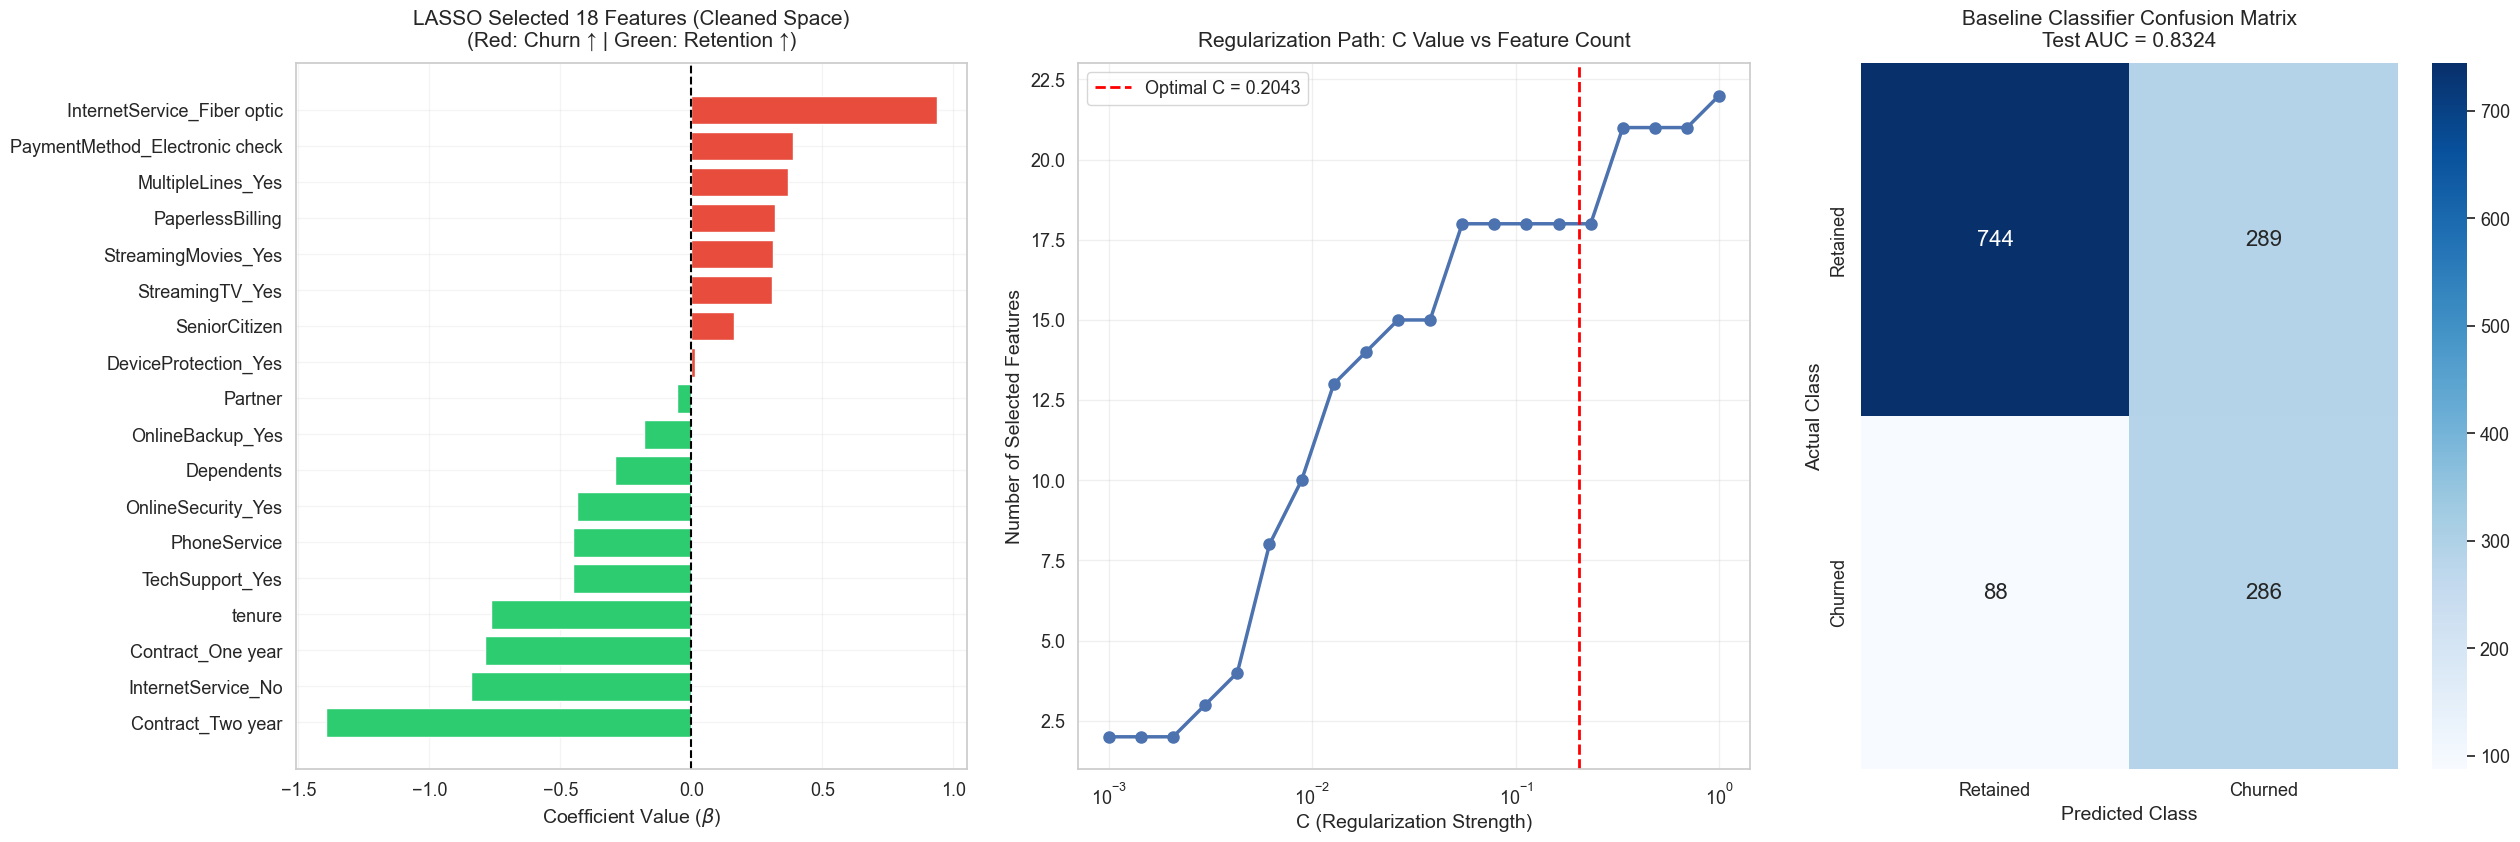


 FİNAL ÖZELLİK SEÇİMİ RAPORU
Korelasyon elenen    : 0 özellik
Korelasyon sonrası   : 22 özellik
LASSO elenen (β=0)   : 3 özellik
Eşik filtresi elenen : 1 özellik
Final seçilen        : 18 özellik
Optimal C            : 0.2043
Test AUC             : 0.8324

--- Seçilen Özellikler (Önem Sırasına Göre) ---
                       Feature  Coefficient
             Contract_Two year    -1.393408
   InternetService_Fiber optic     0.935706
            InternetService_No    -0.841610
             Contract_One year    -0.789677
                        tenure    -0.765868
               TechSupport_Yes    -0.453579
                  PhoneService    -0.451410
            OnlineSecurity_Yes    -0.437406
PaymentMethod_Electronic check     0.389037
             MultipleLines_Yes     0.366941
              PaperlessBilling     0.318720
           StreamingMovies_Yes     0.312765
               StreamingTV_Yes     0.308482
                    Dependents    -0.291033
              OnlineBackup_Yes    

In [31]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── ADIM 1: KORELASYON BAZLI ELEME ──────────────────────────────
def remove_high_corr(df, threshold=0.85):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return df.drop(columns=to_drop), to_drop

X_train_clean, dropped_cols = remove_high_corr(X_train_bal, threshold=0.85)
X_test_clean = X_test.drop(columns=dropped_cols, errors='ignore')

print(f"Elenen (korelasyon) : {len(dropped_cols)} özellik → {dropped_cols}")
print(f"Kalan özellik sayısı: {X_train_clean.shape[1]}")

# ── ADIM 2: LASSO — TEMİZLENMİŞ VERİYLE ────────────────────────
lasso_cv = LogisticRegressionCV(
    Cs=np.logspace(-4, 0, 30),
    penalty='l1',
    solver='saga',
    cv=5,
    scoring='roc_auc',
    max_iter=2000,
    random_state=42,
    n_jobs=-1
)
lasso_cv.fit(X_train_clean, y_train_bal)
optimal_c = lasso_cv.C_[0]
print(f"\nOptimal C (CV): {optimal_c:.4f}")

# Katsayı tablosu
df_lasso = pd.DataFrame({
    'Feature': X_train_clean.columns,
    'Coefficient': lasso_cv.coef_[0],
    'Absolute_Coefficient': np.abs(lasso_cv.coef_[0])
}).sort_values(by='Absolute_Coefficient', ascending=False)

# LASSO tarafından sıfırlananlar
df_lasso_selected = df_lasso[df_lasso['Coefficient'] != 0].reset_index(drop=True)
df_lasso_eliminated = df_lasso[df_lasso['Coefficient'] == 0].reset_index(drop=True)

print(f"LASSO seçilen  : {len(df_lasso_selected)}")
print(f"LASSO elenen   : {len(df_lasso_eliminated)} → {df_lasso_eliminated['Feature'].tolist()}")

# ── ADIM 3: EŞİK FİLTRESİ (|β| > 1e-4) ─────────────────────────
threshold = 1e-4
df_final = df_lasso_selected[
    df_lasso_selected['Absolute_Coefficient'] > threshold
].reset_index(drop=True)

df_threshold_eliminated = df_lasso_selected[
    df_lasso_selected['Absolute_Coefficient'] <= threshold
]

print(f"\nEşik filtresi elenen: {df_threshold_eliminated['Feature'].tolist()}")
print(f"Final özellik sayısı: {len(df_final)}")

final_selected_features = df_final['Feature'].tolist()

# ── ADIM 4: BASELINE MODEL (Ridge) ──────────────────────────────
X_train_final = X_train_clean[final_selected_features]
X_test_final  = X_test_clean[final_selected_features]

perf_model = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    C=1.0,
    max_iter=2000,
    random_state=42
)
perf_model.fit(X_train_final, y_train_bal)

y_pred = perf_model.predict(X_test_final)
y_prob = perf_model.predict_proba(X_test_final)[:, 1]
auc    = roc_auc_score(y_test, y_prob)

print(f"\nTest AUC: {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ── ADIM 5: GÖRSELLEŞTİRME ─────────────────────────────────────
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
})

fig, axes = plt.subplots(1, 3, figsize=(26, 9))

# PANEL 1: Seçilen 18 özellik — yönlü katsayı grafiği
df_plot = df_final.sort_values(by='Coefficient', ascending=True)
colors  = ['#e74c3c' if c > 0 else '#2ecc71' for c in df_plot['Coefficient']]

axes[0].barh(df_plot['Feature'], df_plot['Coefficient'], color=colors)
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_title(
    f'LASSO Selected {len(df_final)} Features (Cleaned Space)\n'
    f'(Red: Churn ↑ | Green: Retention ↑)',
    fontsize=15, pad=12
)
axes[0].set_xlabel(r'Coefficient Value ($\beta$)', fontsize=14)
axes[0].tick_params(axis='y', labelsize=13)
axes[0].grid(True, alpha=0.2)

# PANEL 2: C vs Seçilen Özellik Sayısı (elbow plot)
c_values        = np.logspace(-3, 0, 20)
n_selected_list = []

for c in c_values:
    m = LogisticRegression(
        penalty='l1', solver='saga', C=c,
        max_iter=2000, random_state=42
    )
    m.fit(X_train_clean, y_train_bal)
    n_selected_list.append(np.sum(m.coef_[0] != 0))

axes[1].plot(c_values, n_selected_list, 'bo-', linewidth=2.5, markersize=8)
axes[1].axvline(
    x=optimal_c, color='red', linestyle='--', linewidth=2,
    label=f'Optimal C = {optimal_c:.4f}'
)
axes[1].set_xscale('log')
axes[1].set_xlabel('C (Regularization Strength)', fontsize=14)
axes[1].set_ylabel('Number of Selected Features', fontsize=14)
axes[1].set_title('Regularization Path: C Value vs Feature Count', fontsize=15, pad=12)
axes[1].legend(fontsize=13)
axes[1].grid(True, alpha=0.3)

# PANEL 3: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
    xticklabels=['Retained', 'Churned'],
    yticklabels=['Retained', 'Churned'],
    annot_kws={'size': 16}
)
axes[2].set_title(
    f'Baseline Classifier Confusion Matrix\nTest AUC = {auc:.4f}',
    fontsize=15, pad=12
)
axes[2].set_ylabel('Actual Class', fontsize=14)
axes[2].set_xlabel('Predicted Class', fontsize=14)
axes[2].tick_params(axis='both', labelsize=13)

plt.tight_layout(pad=2.0)
plt.savefig('lasso_final_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ── ÖZET RAPOR ──────────────────────────────────────────────────
print("\n" + "="*55)
print(" FİNAL ÖZELLİK SEÇİMİ RAPORU")
print("="*55)
print(f"Korelasyon elenen    : {len(dropped_cols)} özellik")
print(f"Korelasyon sonrası   : {X_train_clean.shape[1]} özellik")
print(f"LASSO elenen (β=0)   : {len(df_lasso_eliminated)} özellik")
print(f"Eşik filtresi elenen : {len(df_threshold_eliminated)} özellik")
print(f"Final seçilen        : {len(df_final)} özellik")
print(f"Optimal C            : {optimal_c:.4f}")
print(f"Test AUC             : {auc:.4f}")
print("\n--- Seçilen Özellikler (Önem Sırasına Göre) ---")
print(df_final[['Feature', 'Coefficient']].to_string(index=False))
print(f"\n✓ 'final_selected_features' listesi hazır ({len(final_selected_features)} özellik)")


In [32]:
# MonthlyCharges'ı gerçekten sıfır mı kontrol et, temizle
print(f"MonthlyCharges katsayısı: {lasso_clean.coef_[0][list(X_train_clean.columns).index('MonthlyCharges')]:.10f}")

# Eşik koy — 1e-4'ten küçük katsayıları sıfır say
df_selected_clean = df_clean[df_clean['Absolute_Coefficient'] > 1e-4].reset_index(drop=True)
df_eliminated_clean = df_clean[df_clean['Absolute_Coefficient'] <= 1e-4].reset_index(drop=True)

final_selected_features = df_selected_clean['Feature'].tolist()
print(f"Temizlenmiş seçilen özellik sayısı: {len(final_selected_features)}")

MonthlyCharges katsayısı: 0.0000018342
Temizlenmiş seçilen özellik sayısı: 18


Modelleme için seçilen özellik sayısı: 18
Kullanılan özellikler: ['Contract_Two year', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'tenure', 'TechSupport_Yes', 'PhoneService', 'OnlineSecurity_Yes', 'PaymentMethod_Electronic check', 'MultipleLines_Yes', 'PaperlessBilling', 'StreamingMovies_Yes', 'StreamingTV_Yes', 'Dependents', 'OnlineBackup_Yes', 'SeniorCitizen', 'Partner', 'DeviceProtection_Yes']



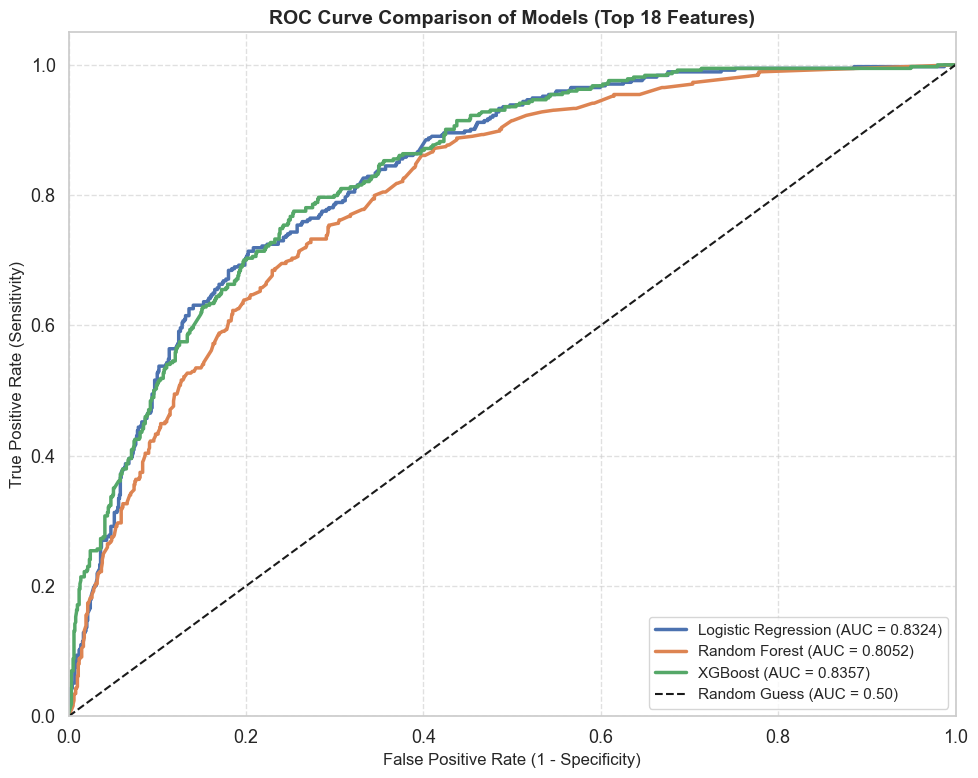


 MODEL PERFORMANS KARŞILAŞTIRMA TABLOSU
              Model Accuracy Precision Recall F1-Score ROC-AUC
Logistic Regression   0.7321    0.4974 0.7647   0.6027  0.8324
      Random Forest   0.7768    0.5909 0.5214   0.5540  0.8052
            XGBoost   0.7882    0.5964 0.6283   0.6120  0.8357


In [ ]:
#son modelleme kısmı için final olarak lasso seçildi
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. TEMİZLENMİŞ 18 ÖZELLİĞİN FİLTRELENMESİ
top_18_features = final_selected_features  # df_selected_clean'den gelen temizlenmiş liste
X_train_model = X_train_clean[top_18_features]
X_test_model = X_test_clean[top_18_features]

print(f"Modelleme için seçilen özellik sayısı: {X_train_model.shape[1]}")
print(f"Kullanılan özellikler: {top_18_features}\n")

# 2. MODELLERİN TANIMLANMASI
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5,
                              eval_metric='logloss', random_state=42, verbosity=0)
}

# 3. MODELLERİN EĞİTİLMESİ VE PERFORMANS ÖLÇÜMÜ
comparison_metrics = []
plt.figure(figsize=(10, 8))

for model_name, model in models.items():
    model.fit(X_train_model, y_train_bal)
    
    y_pred = model.predict(X_test_model)
    y_prob = model.predict_proba(X_test_model)[:, 1]
    
    comparison_metrics.append({
        'Model': model_name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob)
    })
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc_score(y_test, y_prob):.4f})', linewidth=2.5)

# 4. ROC CURVE
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve Comparison of Models (Top 18 Features)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('model_comparison_roc_curve.png', dpi=150)
plt.show()

# 5. KARŞILAŞTIRMA TABLOSU
df_comparison = pd.DataFrame(comparison_metrics)
print("\n" + "="*70)
print(" MODEL PERFORMANS KARŞILAŞTIRMA TABLOSU")
print("="*70)
print(df_comparison.to_string(index=False, formatters={
    'Accuracy':  '{:.4f}'.format,
    'Precision': '{:.4f}'.format,
    'Recall':    '{:.4f}'.format,
    'F1-Score':  '{:.4f}'.format,
    'ROC-AUC':   '{:.4f}'.format
}))

In [34]:
#bu model kullanılacak f1, 
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score, accuracy_score
import numpy as np

# 1. PARAMETRE UZAYI
param_dist = {
    'n_estimators':    [100, 200, 300, 500],
    'max_depth':       [3, 4, 5, 6, 7],
    'learning_rate':   [0.01, 0.05, 0.1, 0.2],
    'subsample':       [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree':[0.6, 0.7, 0.8, 1.0],
    'min_child_weight':[1, 3, 5],
    'gamma':           [0, 0.1, 0.3, 0.5]
}
param_dist['scale_pos_weight'] = [1, 2, 2.77, 4]

# 2. RANDOMIZED SEARCH
xgb_base = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    verbosity=0,
    scale_pos_weight=5174/1869
)
search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring='f1',        # ← 'roc_auc' yerine
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_model, y_train_bal)

# 3. EN İYİ MODEL
best_xgb = search.best_estimator_
print(f"En iyi parametreler:\n{search.best_params_}\n")

# 4. PERFORMANS KARŞILAŞTIRMASI
y_pred_tuned = best_xgb.predict(X_test_model)
y_prob_tuned = best_xgb.predict_proba(X_test_model)[:, 1]

# Baseline XGBoost (tune öncesi)
xgb_base_model = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5,
                                 eval_metric='logloss', random_state=42, verbosity=0)
xgb_base_model.fit(X_train_model, y_train_bal)
y_prob_base = xgb_base_model.predict_proba(X_test_model)[:, 1]
y_pred_base = xgb_base_model.predict(X_test_model)

print("="*55)
print(" TUNE ÖNCESİ vs SONRASI — XGBoost")
print("="*55)
print(f"{'Metrik':<15} {'Öncesi':>10} {'Sonrası':>10} {'Fark':>10}")
print("-"*55)
for metrik, once, sonra in [
    ('AUC',       roc_auc_score(y_test, y_prob_base),          roc_auc_score(y_test, y_prob_tuned)),
    ('F1',        f1_score(y_test, y_pred_base),                f1_score(y_test, y_pred_tuned)),
    ('Recall',    recall_score(y_test, y_pred_base),            recall_score(y_test, y_pred_tuned)),
    ('Precision', precision_score(y_test, y_pred_base),         precision_score(y_test, y_pred_tuned)),
    ('Accuracy',  accuracy_score(y_test, y_pred_base),          accuracy_score(y_test, y_pred_tuned)),
]:
    fark = sonra - once
    isaret = "+" if fark >= 0 else ""
    print(f"{metrik:<15} {once:>10.4f} {sonra:>10.4f} {isaret}{fark:>9.4f}")
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.2, 0.7, 0.01)
f1_scores = [f1_score(y_test, (y_prob_tuned > t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"En iyi threshold: {best_threshold:.2f} → F1: {max(f1_scores):.4f}")
y_pred_best = (y_prob_tuned > best_threshold).astype(int)

print(f"\nThreshold {best_threshold:.2f} ile:")
print(f"F1:        {f1_score(y_test, y_pred_best):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")



# 5. SONRAKİ ADIM İÇİN KAYDET
final_model = best_xgb
print(f"\n✓ final_model hazır — sonraki adım: SHAP yorumlanabilirlik")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
En iyi parametreler:
{'subsample': 0.6, 'scale_pos_weight': 2, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.8}

 TUNE ÖNCESİ vs SONRASI — XGBoost
Metrik              Öncesi    Sonrası       Fark
-------------------------------------------------------
AUC                 0.8357     0.8344   -0.0013
F1                  0.6120     0.6148 +   0.0028
Recall              0.6283     0.8021 +   0.1738
Precision           0.5964     0.4983   -0.0981
Accuracy            0.7882     0.7328   -0.0554
En iyi threshold: 0.63 → F1: 0.6282

Threshold 0.63 ile:
F1:        0.6282
Recall:    0.6979
Precision: 0.5711

✓ final_model hazır — sonraki adım: SHAP yorumlanabilirlik


Modelleme için seçilen özellik sayısı: 18
Kullanılan özellikler: ['Contract_Two year', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'tenure', 'TechSupport_Yes', 'PhoneService', 'OnlineSecurity_Yes', 'PaymentMethod_Electronic check', 'MultipleLines_Yes', 'PaperlessBilling', 'StreamingMovies_Yes', 'StreamingTV_Yes', 'Dependents', 'OnlineBackup_Yes', 'SeniorCitizen', 'Partner', 'DeviceProtection_Yes']



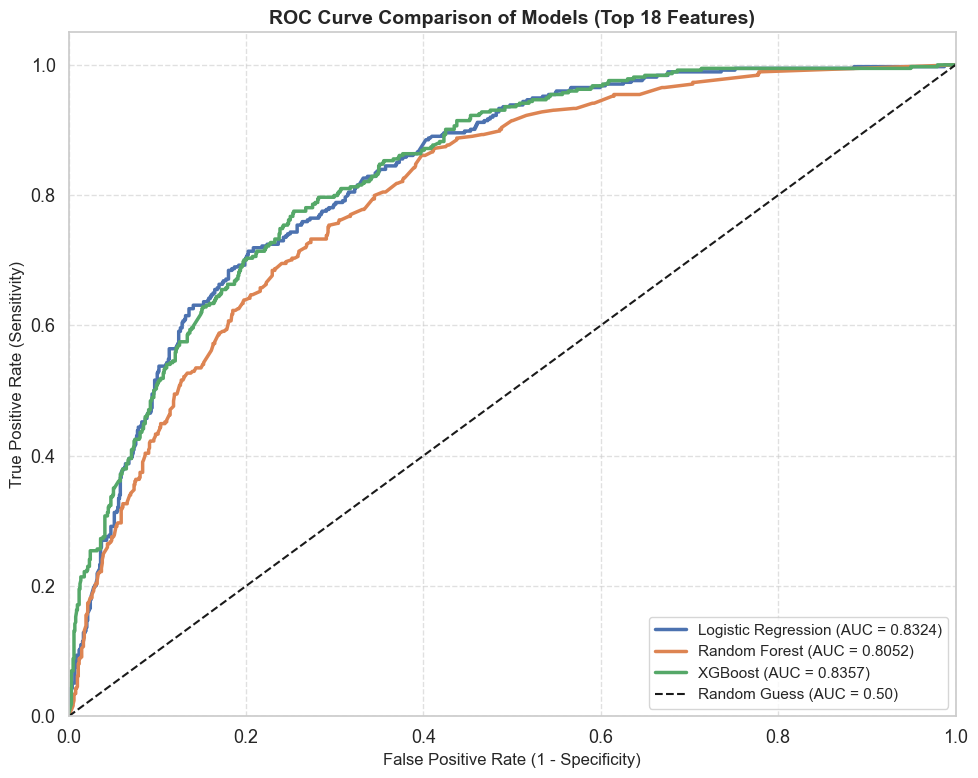


 MODEL PERFORMANS KARŞILAŞTIRMA TABLOSU
              Model Accuracy Precision Recall F1-Score ROC-AUC
Logistic Regression   0.7321    0.4974 0.7647   0.6027  0.8324
      Random Forest   0.7768    0.5909 0.5214   0.5540  0.8052
            XGBoost   0.7882    0.5964 0.6283   0.6120  0.8357


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. TEMİZLENMİŞ 18 ÖZELLİĞİN FİLTRELENMESİ
top_18_features = final_selected_features  # df_selected_clean'den gelen temizlenmiş liste
X_train_model = X_train_clean[top_18_features]
X_test_model = X_test_clean[top_18_features]

print(f"Modelleme için seçilen özellik sayısı: {X_train_model.shape[1]}")
print(f"Kullanılan özellikler: {top_18_features}\n")

# 2. MODELLERİN TANIMLANMASI
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5,
                              eval_metric='logloss', random_state=42, verbosity=0)
}

# 3. MODELLERİN EĞİTİLMESİ VE PERFORMANS ÖLÇÜMÜ
comparison_metrics = []
plt.figure(figsize=(10, 8))

for model_name, model in models.items():
    model.fit(X_train_model, y_train_bal)
    
    y_pred = model.predict(X_test_model)
    y_prob = model.predict_proba(X_test_model)[:, 1]
    
    comparison_metrics.append({
        'Model': model_name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob)
    })
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc_score(y_test, y_prob):.4f})', linewidth=2.5)

# 4. ROC CURVE
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve Comparison of Models (Top 18 Features)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('model_comparison_roc_curve.png', dpi=150)
plt.show()

# 5. KARŞILAŞTIRMA TABLOSU
df_comparison = pd.DataFrame(comparison_metrics)
print("\n" + "="*70)
print(" MODEL PERFORMANS KARŞILAŞTIRMA TABLOSU")
print("="*70)
print(df_comparison.to_string(index=False, formatters={
    'Accuracy':  '{:.4f}'.format,
    'Precision': '{:.4f}'.format,
    'Recall':    '{:.4f}'.format,
    'F1-Score':  '{:.4f}'.format,
    'ROC-AUC':   '{:.4f}'.format
}))

In [36]:
!pip install shap

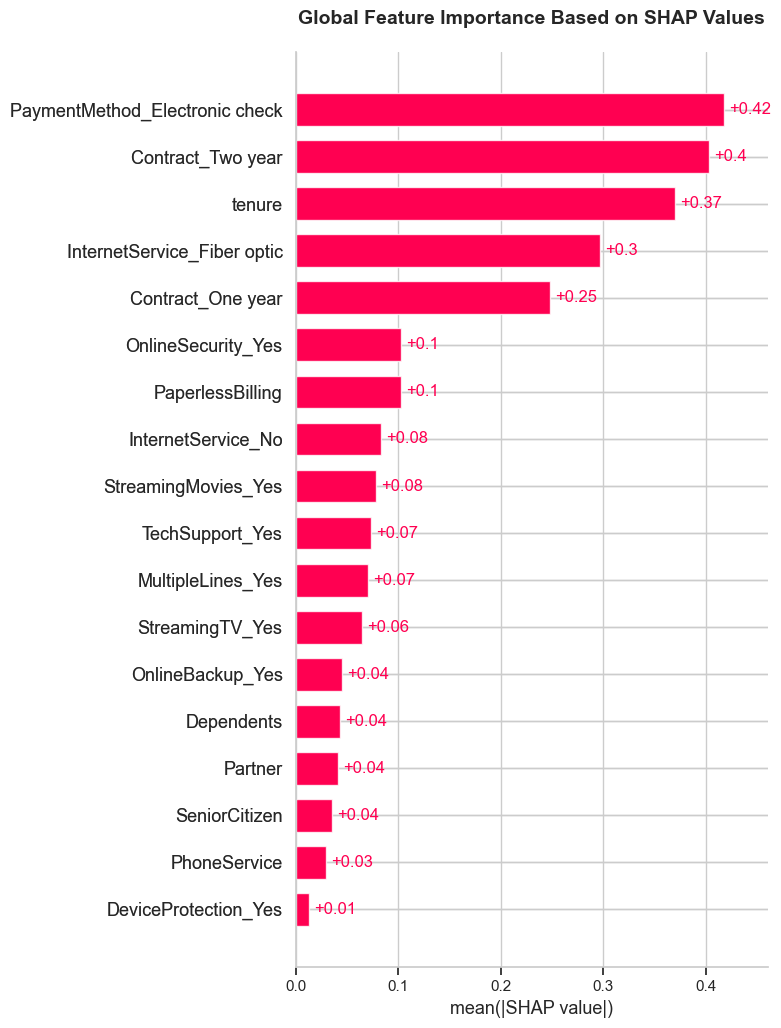

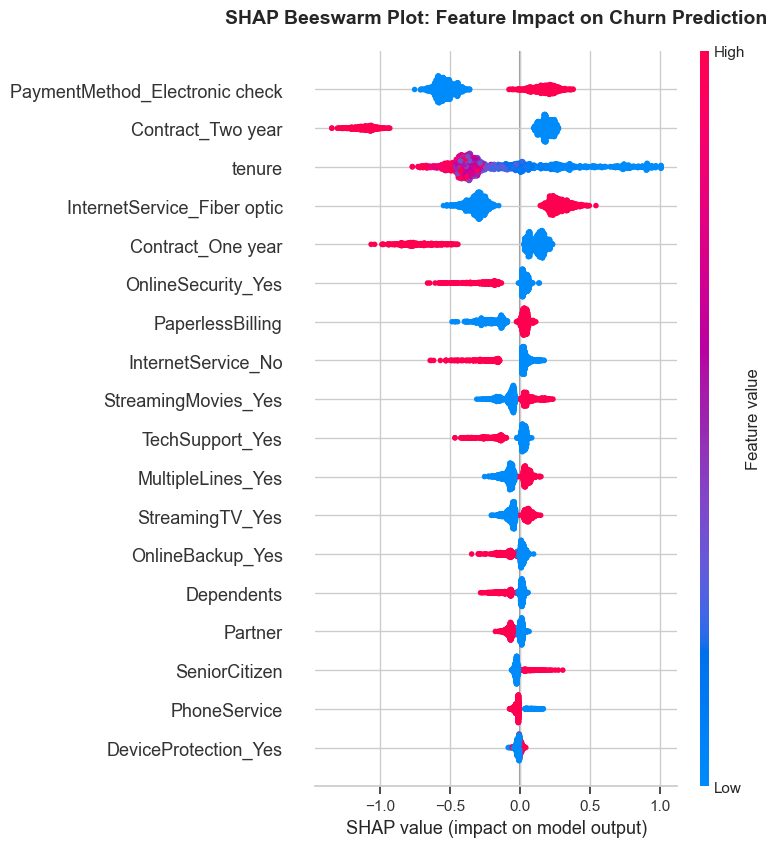

In [37]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_test_model)

# Grafik 1: Bar
shap.plots.bar(shap_values, max_display=18, show=False)
plt.title('Global Feature Importance Based on SHAP Values', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Grafik 2: Beeswarm
shap.plots.beeswarm(shap_values, max_display=18, show=False)
plt.title('SHAP Beeswarm Plot: Feature Impact on Churn Prediction', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_beeswarm_plot.png', dpi=150, bbox_inches='tight')
plt.show()